# Employee Attrition Analytics

## Module 7: Machine Learning

### Objective
Build and evaluate machine learning models to predict whether an employee will leave the company.

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

## Load ML-Ready Dataset

In [23]:
df = pd.read_csv("../data/processed/employee_attrition_ml_ready.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 52)


,Age,Gender,Experience,Salary,Performance_Score,Job_Satisfaction,Overtime,Work_Hours,Remote_Work,Training_Hours,...,Salary_Band_Medium,Salary_Band_High,Salary_Band_Very High,Experience_Band_Junior,Experience_Band_Mid Level,Experience_Band_Senior,Satisfaction_Category_Medium,Satisfaction_Category_High,Performance_Category_Average,Performance_Category_High
0,40.0,0,3,94113.0,5,6.0,1,46,0,70,...,1,0,0,1,0,0,1,0,0,1
1,39.0,1,2,54224.0,4,9.0,0,36,0,33,...,0,0,0,0,0,0,0,1,0,1
2,49.0,0,25,166749.0,2,6.0,0,48,1,75,...,0,1,0,0,0,1,1,0,0,0
3,54.0,1,26,196590.0,5,4.0,1,51,1,64,...,0,0,1,0,0,1,0,0,0,1
4,41.0,1,18,231764.0,3,8.0,1,40,1,15,...,0,0,1,0,0,1,0,1,1,0


In [ ]:
# Check for non-numeric columns
non_numeric_columns = X.select_dtypes(exclude=np.number).columns

print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
[]


In [25]:
# Display unique values of remaining non-numeric columns

for column in non_numeric_columns:
    print(f"\n{column}:")
    print(X[column].unique())

## Separate Features and Target

In [26]:
X = df.drop(columns=["Attrition", "Attrition_Target"])
y = df["Attrition_Target"]

print("Featue shape:", X.shape)
print("Target shape:", y.shape)

Featue shape: (1000, 50)
Target shape: (1000,)


## Inspect Target Distribution

In [27]:
target_counts = y.value_counts()
print(target_counts)

Attrition_Target
0    882
1    118
Name: count, dtype: int64


In [28]:
target_percentage = (y.value_counts(normalize=True) * 100).round(2)
print(target_percentage)

Attrition_Target
0    88.2
1    11.8
Name: proportion, dtype: float64


## Visualize Target Distribution

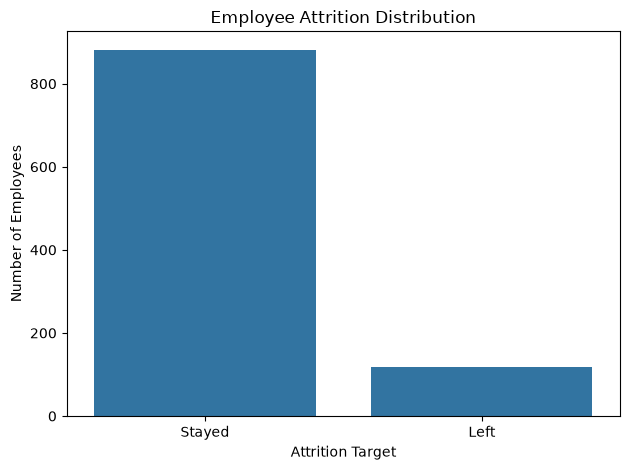

In [29]:
plt.Figure(figsize=(7, 5))

sns.countplot(x=y)
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition Target")
plt.ylabel("Number of Employees")

plt.xticks([0, 1], ["Stayed", "Left"])
plt.tight_layout()
plt.show()

In [ ]:
X["Promotion_Last_5Yrs"] = X["Promotion_Last_5Yrs"].map({"No": 0, "Yes": 1})

print(X["Promotion_Last_5Yrs"].value_counts())

Promotion_Last_5Yrs
0    794
1    206
Name: count, dtype: int64


In [ ]:
non_numeric_columns = X.select_dtypes(exclude=np.number).columns

print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
[]


## Split Data into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (800, 50)
Testing features: (200, 50)


## Verify Target Distribution After Split

In [39]:
print("Training target distribution")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution
Attrition_Target
0    0.882
1    0.118
Name: proportion, dtype: float64

Testing target distribution
Attrition_Target
0    0.88
1    0.12
Name: proportion, dtype: float64


## Baseline Model

The baseline model always predicts the majority class.

This provides a reference point for evaluating our machine learning models.

In [40]:
majority_class = y_train.mode()[0]

baseline_predictions = np.full(shape=len(y_test), fill_value=majority_class)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", round(baseline_accuracy, 4))

Baseline Accuracy: 0.88


## Logistic Regression

Logistic Regression will be used as our first classification model.

It provides a simple and interpretable baseline for binary classification.

In [46]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/Users/huzaifa/Desktop/Huzaifa/Learning/DataScience/Projects/employee-attrition-analytics/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Logistic Regression Predictions

In [49]:
y_pred_logistic = logistic_model.predict(X_test)

y_pred_logistic[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Prediction Probabilities

In [50]:
y_probability_logistic = logistic_model.predict_proba(
    X_test
)[:, 1]

y_probability_logistic[:10]

array([9.95289366e-05, 1.01888082e-01, 3.51369522e-03, 9.64903502e-04,
       1.21269356e-02, 2.04706957e-02, 4.27628588e-01, 7.04187639e-04,
       1.01540524e-03, 1.25081436e-02])

## Evaluate Logistic Regression

In [51]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

print("Logistic Regression")
print("=" * 30)

print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Logistic Regression
Accuracy : 0.97
Precision: 0.875
Recall   : 0.875
F1 Score : 0.875


## Logistic Regression Classification Report

In [52]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Stayed", "Left"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Stayed       0.98      0.98      0.98       176
        Left       0.88      0.88      0.88        24

    accuracy                           0.97       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.97      0.97      0.97       200



## Logistic Regression Confusion Matrix

In [53]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm_logistic)

[[173   3]
 [  3  21]]


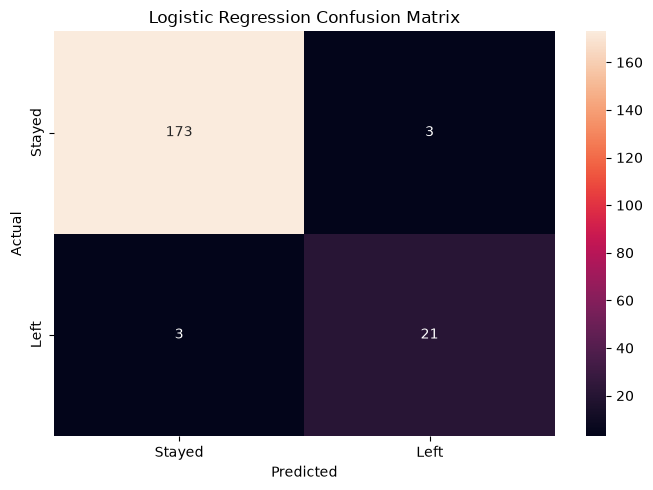

In [54]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Decision Tree Classifier

In [55]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Decision Tree Predictions

In [56]:
y_pred_tree = decision_tree.predict(
    X_test
)

y_pred_tree[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

## Evaluate Decision Tree

In [57]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

print("Decision Tree")
print("=" * 30)

print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))

Decision Tree
Accuracy : 0.935
Precision: 0.7619
Recall   : 0.6667
F1 Score : 0.7111


## Decision Tree Classification Report

In [58]:
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Stayed", "Left"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Stayed       0.96      0.97      0.96       176
        Left       0.76      0.67      0.71        24

    accuracy                           0.94       200
   macro avg       0.86      0.82      0.84       200
weighted avg       0.93      0.94      0.93       200



## Random Forest Classifier

Random Forest combines multiple decision trees to improve predictive performance and reduce the limitations of a single tree.

In [59]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Random Forest Predictions

In [60]:
y_pred_forest = random_forest.predict(
    X_test
)

y_pred_forest[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

## Evaluate Random Forest

In [61]:
forest_accuracy = accuracy_score(
    y_test,
    y_pred_forest
)

forest_precision = precision_score(
    y_test,
    y_pred_forest,
    zero_division=0
)

forest_recall = recall_score(
    y_test,
    y_pred_forest,
    zero_division=0
)

forest_f1 = f1_score(
    y_test,
    y_pred_forest,
    zero_division=0
)

print("Random Forest")
print("=" * 30)

print("Accuracy :", round(forest_accuracy, 4))
print("Precision:", round(forest_precision, 4))
print("Recall   :", round(forest_recall, 4))
print("F1 Score :", round(forest_f1, 4))

Random Forest
Accuracy : 0.935
Precision: 0.7619
Recall   : 0.6667
F1 Score : 0.7111


## Random Forest Classification Report

In [62]:
print(
    classification_report(
        y_test,
        y_pred_forest,
        target_names=["Stayed", "Left"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Stayed       0.96      0.97      0.96       176
        Left       0.76      0.67      0.71        24

    accuracy                           0.94       200
   macro avg       0.86      0.82      0.84       200
weighted avg       0.93      0.94      0.93       200



## Random Forest Confusion Matrix

In [63]:
cm_forest = confusion_matrix(
    y_test,
    y_pred_forest
)

print(cm_forest)

[[171   5]
 [  8  16]]


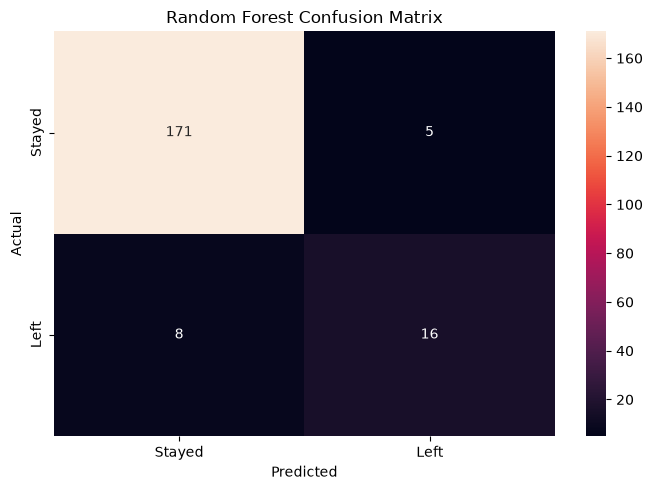

In [64]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Model Performance Comparison

In [65]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        np.nan,
        logistic_precision,
        tree_precision,
        forest_precision
    ],
    "Recall": [
        np.nan,
        logistic_recall,
        tree_recall,
        forest_recall
    ],
    "F1_Score": [
        np.nan,
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1_Score
0,Baseline,0.880,NaN,NaN,NaN
1,Logistic Regression,0.970,0.8750,0.8750,0.8750
2,Decision Tree,0.935,0.7619,0.6667,0.7111
3,Random Forest,0.935,0.7619,0.6667,0.7111


## Rank Models by F1 Score

In [66]:
model_results.sort_values(
    by="F1_Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score
1,Logistic Regression,0.970,0.875000,0.875000,0.875000
2,Decision Tree,0.935,0.761905,0.666667,0.711111
3,Random Forest,0.935,0.761905,0.666667,0.711111
0,Baseline,0.880,NaN,NaN,NaN


## Compare Model Performance

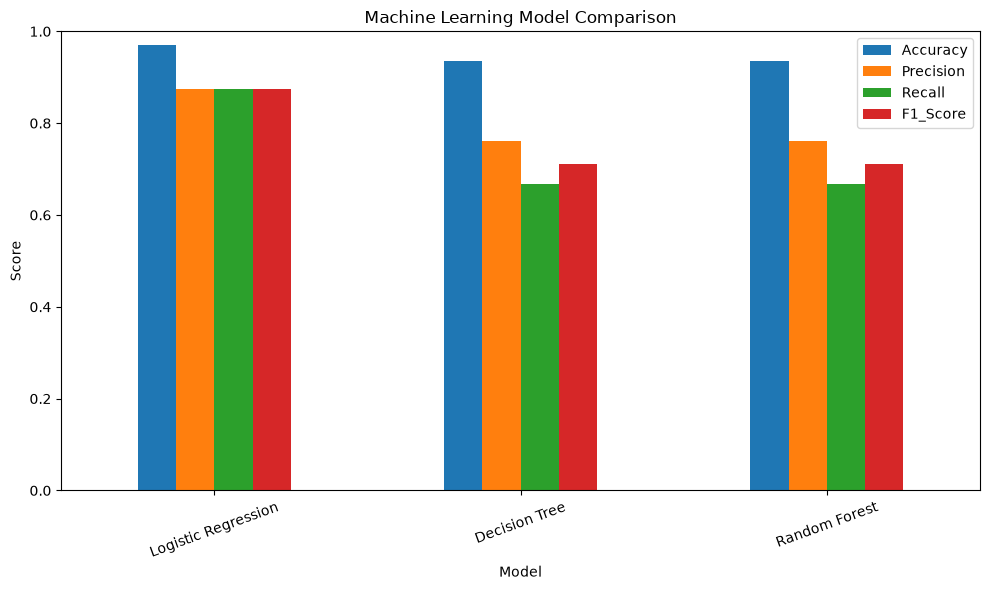

In [67]:
comparison_plot = model_results[
    model_results["Model"] != "Baseline"
].set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1_Score"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Random Forest Feature Importance

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
5,Job_Satisfaction,0.369765
46,Satisfaction_Category_Medium,0.087381
47,Satisfaction_Category_High,0.068819
6,Overtime,0.066617
16,Salary_Per_Experience,0.033952
9,Training_Hours,0.031390
14,Years_At_Company,0.030263
3,Salary,0.026028
17,Workload_Score,0.025272
0,Age,0.024627


## Top 15 Important Features

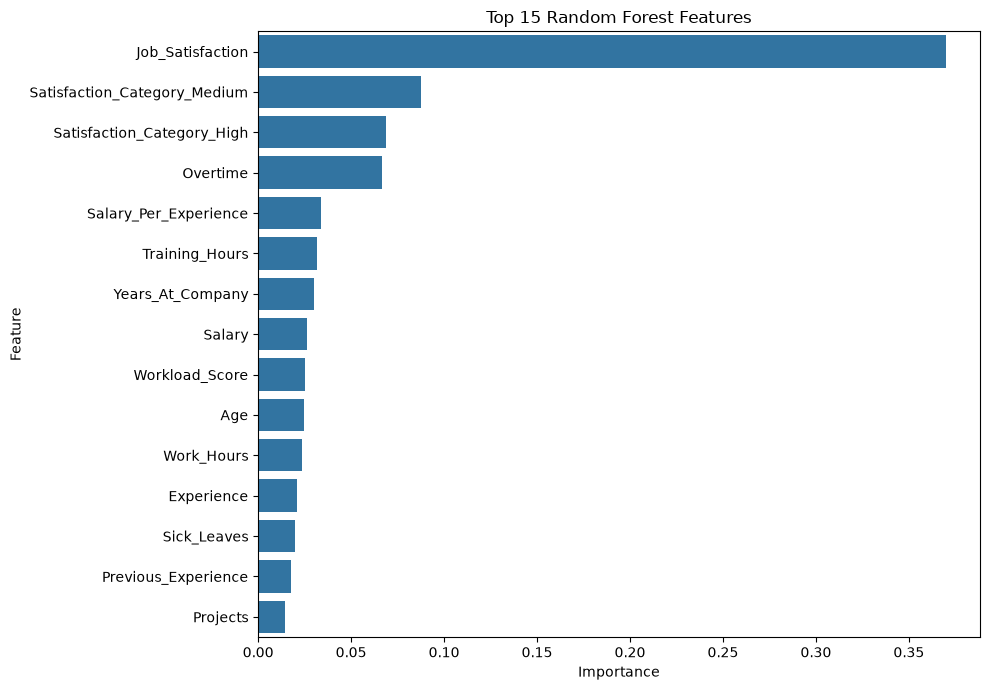

In [69]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Select Best Model

In [70]:
model_results_without_baseline = model_results.dropna(
    subset=["F1_Score"]
)

best_model_name = (
    model_results_without_baseline
    .sort_values("F1_Score", ascending=False)
    .iloc[0]["Model"]
)

best_f1 = (
    model_results_without_baseline
    .sort_values("F1_Score", ascending=False)
    .iloc[0]["F1_Score"]
)

print("Best model:", best_model_name)
print("Best F1 Score:", round(best_f1, 4))

Best model: Logistic Regression
Best F1 Score: 0.875


## Save Model Comparison

In [71]:
model_results.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


## Save Feature Importance

In [72]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


## Final Model Evaluation

In [73]:
print("MODEL PERFORMANCE")
print("=" * 50)

for _, row in model_results.iterrows():
    print(f"\n{row['Model']}")

    print(
        f"Accuracy : "
        f"{row['Accuracy']:.4f}"
    )

    if not pd.isna(row["F1_Score"]):
        print(
            f"Precision: "
            f"{row['Precision']:.4f}"
        )

        print(
            f"Recall   : "
            f"{row['Recall']:.4f}"
        )

        print(
            f"F1 Score : "
            f"{row['F1_Score']:.4f}"
        )

MODEL PERFORMANCE

Baseline
Accuracy : 0.8800

Logistic Regression
Accuracy : 0.9700
Precision: 0.8750
Recall   : 0.8750
F1 Score : 0.8750

Decision Tree
Accuracy : 0.9350
Precision: 0.7619
Recall   : 0.6667
F1 Score : 0.7111

Random Forest
Accuracy : 0.9350
Precision: 0.7619
Recall   : 0.6667
F1 Score : 0.7111
